<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Check_UnbalanceTechnique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall, AUC

from imblearn.over_sampling import SMOTE
from tensorflow.keras.metrics import AUC, Precision, Recall
import tensorflow as tf

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE


In [31]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [32]:
# Copy data
data = df.copy()

In [33]:
data['AvgChargePerMonth'] = data['TotalCharges_numeric'] / (data['tenure'] + 1)

service_yes_cols = [
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',  # real service
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]
data['ServiceCount'] = data[service_yes_cols].sum(axis=1)

# Check first few rows to confirm
data[['AvgChargePerMonth', 'ServiceCount']].head()

,AvgChargePerMonth,ServiceCount
0,29.441096,1
1,1283.433962,3
2,105.227027,3
3,1132.769231,3
4,147.551351,2


In [ ]:
data.columns

In [34]:
scaler = MinMaxScaler()

# Columns to scale
cols_to_scale = ['AvgChargePerMonth', 'ServiceCount']

# Fit + transform
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [ ]:
data.columns

In [35]:
drop_cols = [
    'customerID',
    'MonthlyCharges',
    'TotalCharges',
    'TotalCharges_numeric',
    # ServiceCount component cols
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

X = data.drop(columns=drop_cols + ['Churn'])
y = data['Churn']

In [36]:
# Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale features to [0,1] using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shapes and class distribution
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 22) (5634,)
Test shape: (1409, 22) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


# **1. With Class Weights**

In [ ]:
# Calculate class weights
# Classes
classes = np.unique(y_train)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to dictionary
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,  # applies class weights
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Class Weights Only')
plt.show()

# **2. SMOTE**

After SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6649 - auc: 0.7255 - f1_score: 0.4927 - loss: 0.6054 - precision: 0.5694 - recall: 0.5083 - val_accuracy: 0.6769 - val_auc: 0.0000e+00 - val_f1_score: 0.8046 - val_loss: 0.6926 - val_precision: 1.0000 - val_recall: 0.6769
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7548 - auc: 0.8211 - f1_score: 0.6666 - loss: 0.4995 - precision: 0.6797 - recall: 0.6607 - val_accuracy: 0.6570 - val_auc: 0.0000e+00 - val_f1_score: 0.7902 - val_loss: 0.7329 - val_precision: 1.0000 - val_recall: 0.6570
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7627 - auc: 0.8278 - f1_score: 0.6635 - loss: 0.4872 - precision: 0.6814 - recall: 0.6668 - val_accuracy: 0.6793 - val_auc: 0.0000e+00 - val_f1_score: 0.8060 - val_loss: 0.7020 - val_precision: 1.0000 - val_recall: 0.6793
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7602 - auc: 0.8333 - f1_score: 0.6688 - loss: 0.4810 - precision: 0.6762 - recall

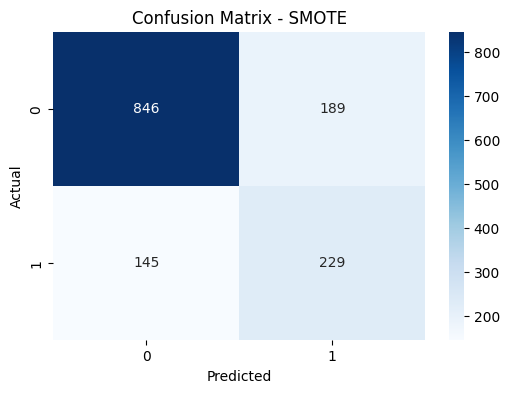

In [38]:
# Initialize SMOTE
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SMOTE')
plt.show()

# **3. Borderline SMOTE - 1**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6945 - auc: 0.7375 - f1_score: 0.4437 - loss: 0.6011 - precision: 0.6549 - recall: 0.3556 - val_accuracy: 0.5845 - val_auc: 0.0000e+00 - val_f1_score: 0.7336 - val_loss: 0.7520 - val_precision: 1.0000 - val_recall: 0.5845
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7405 - auc: 0.8069 - f1_score: 0.6363 - loss: 0.5124 - precision: 0.6519 - recall: 0.6463 - val_accuracy: 0.6365 - val_auc: 0.0000e+00 - val_f1_score: 0.7745 - val_loss: 0.7298 - val_precision: 1.0000 - val_recall: 0.6365
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7451 - auc: 0.8080 - f1_score: 0.6529 - loss: 0.5094 - precision: 0.6623 - recall: 0.6683 - val_accuracy: 0.6407 - val_auc: 0.0000e+00 - val_f1_score: 0.7774 - val_loss: 0.7169 - val_precision: 1.0000 - val_recall: 0.6407
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7446 - auc: 0.8152 - f1_score: 0.6720 - loss: 0.5035 - precision: 0.6634 - recall

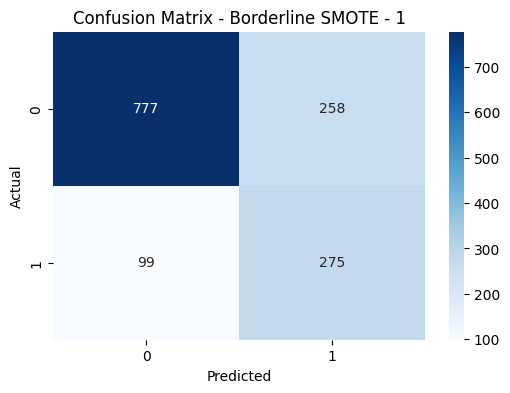

In [39]:
# Initialize Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-1'
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE - 1')
plt.show()

# **4. With Borderline SMOTE - 2**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6698 - auc: 0.7114 - f1_score: 0.4789 - loss: 0.6286 - precision: 0.5889 - recall: 0.4414 - val_accuracy: 0.5278 - val_auc: 0.0000e+00 - val_f1_score: 0.6865 - val_loss: 0.8016 - val_precision: 1.0000 - val_recall: 0.5278
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7323 - auc: 0.7980 - f1_score: 0.6385 - loss: 0.5267 - precision: 0.6545 - recall: 0.6367 - val_accuracy: 0.5181 - val_auc: 0.0000e+00 - val_f1_score: 0.6778 - val_loss: 0.8629 - val_precision: 1.0000 - val_recall: 0.5181
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7343 - auc: 0.8059 - f1_score: 0.6401 - loss: 0.5143 - precision: 0.6530 - recall: 0.6537 - val_accuracy: 0.5175 - val_auc: 0.0000e+00 - val_f1_score: 0.6774 - val_loss: 0.8450 - val_precision: 1.0000 - val_recall: 0.5175
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7440 - auc: 0.8109 - f1_score: 0.6503 - loss: 0.5054 - precision: 0.6547 - recall

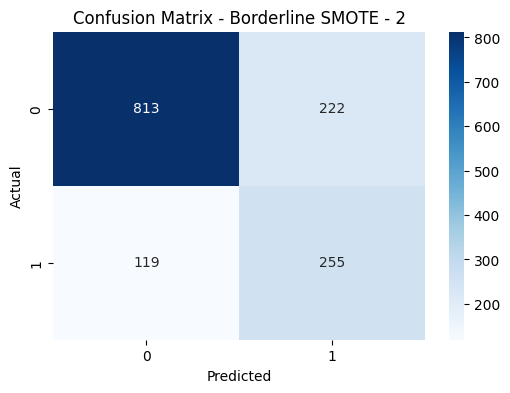

In [40]:
# Initialize Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE - 2')
plt.show()

# **SUMMARY**

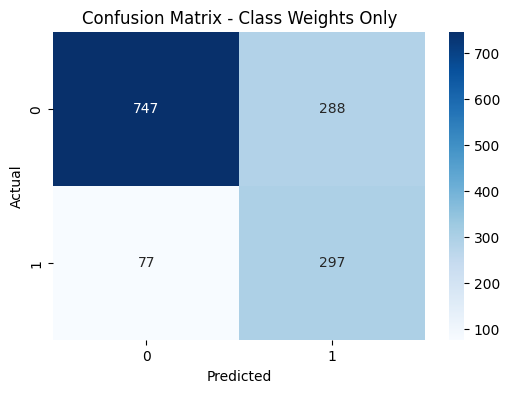

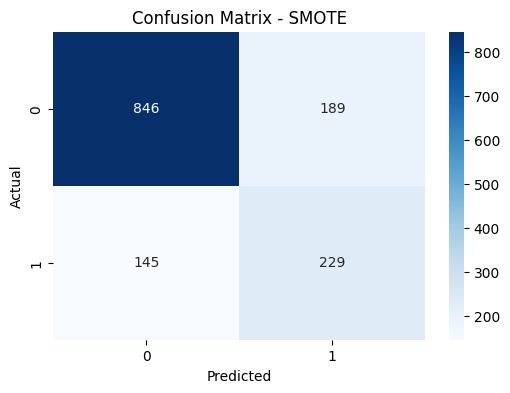

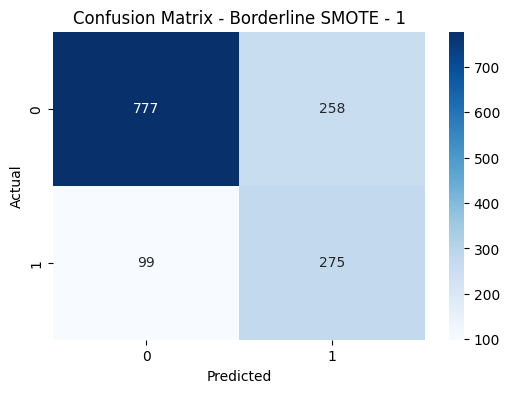

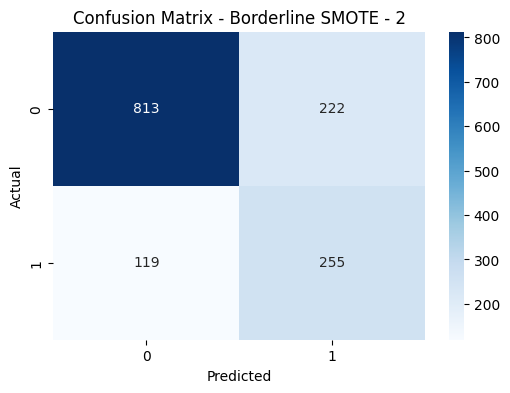